/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_49286/4215583168.py:10: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file)


total events in csv file: 1265657
total events selected: 2278


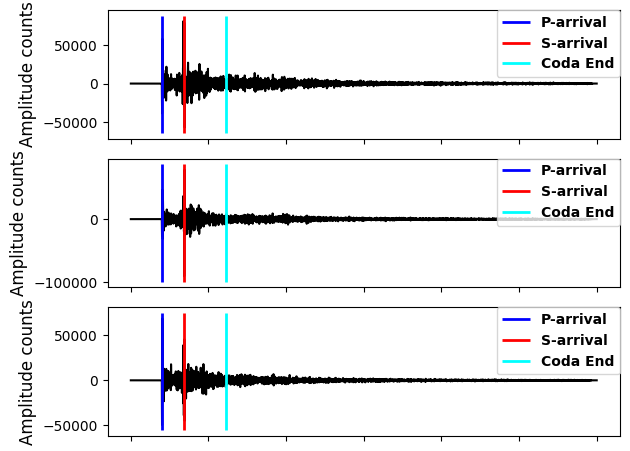

back_azimuth_deg 56.9
coda_end_sample [[1228.]]
network_code CN
p_arrival_sample 400.0
p_status manual
p_travel_sec 4.630000114440918
p_weight 0.5
receiver_code A16
receiver_elevation_m 13.0
receiver_latitude 47.468
receiver_longitude -70.0096
receiver_type HH
s_arrival_sample 686.0
s_status manual
s_weight 0.5
snr_db [72.40000153 61.70000076 62.20000076]
source_depth_km 17.42
source_depth_uncertainty_km 7.6
source_distance_deg 0.18
source_distance_km 19.21
source_error_sec 0.8797
source_gap_deg 37.699
source_horizontal_uncertainty_km 2.68655
source_id 606589340
source_latitude 47.3748
source_longitude -70.2239
source_magnitude 3.7
source_magnitude_author None
source_magnitude_type mb_lg
source_mechanism_strike_dip_rake None
source_origin_time 2015-01-21 05:31:58.92
source_origin_uncertainty_sec 0.76
trace_category earthquake_local
trace_name A16.CN_20150121053158_EV
trace_start_time 2015-01-21 05:31:59.550000


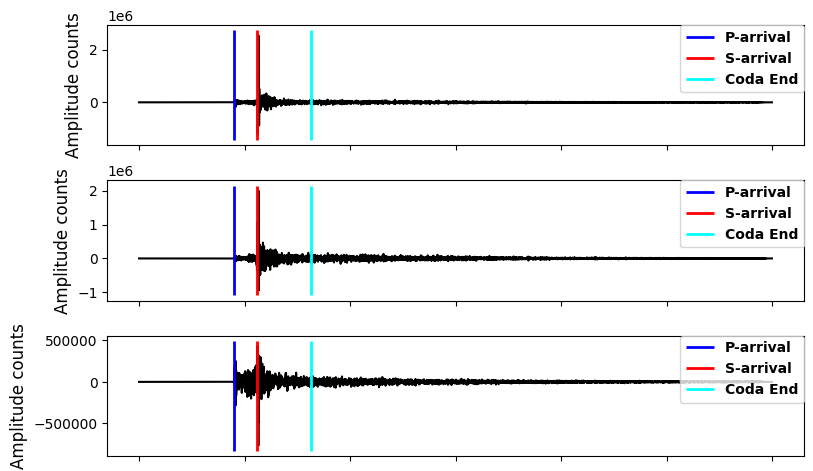

back_azimuth_deg 93.0
coda_end_sample [[1631.]]
network_code CN
p_arrival_sample 900.0
p_status manual
p_travel_sec 4.050000190734863
p_weight 0.5
receiver_code A64
receiver_elevation_m 132.0
receiver_latitude 47.8274
receiver_longitude -69.8914
receiver_type HH
s_arrival_sample 1120.0
s_status manual
s_weight 0.5
snr_db [70.69999695 74.40000153 66.80000305]
source_depth_km 14.69
source_depth_uncertainty_km None
source_distance_deg 0.16
source_distance_km 17.69
source_error_sec 1.3351
source_gap_deg 64.972
source_horizontal_uncertainty_km 4.95069
source_id 603236867
source_latitude 47.8351
source_longitude -70.1274
source_magnitude 4.4
source_magnitude_author None
source_magnitude_type mb
source_mechanism_strike_dip_rake None
source_origin_time 2013-07-11 20:16:07.07
source_origin_uncertainty_sec 0.59
trace_category earthquake_local
trace_name A64.CN_20130711201601_EV
trace_start_time 2013-07-11 20:16:02.120000


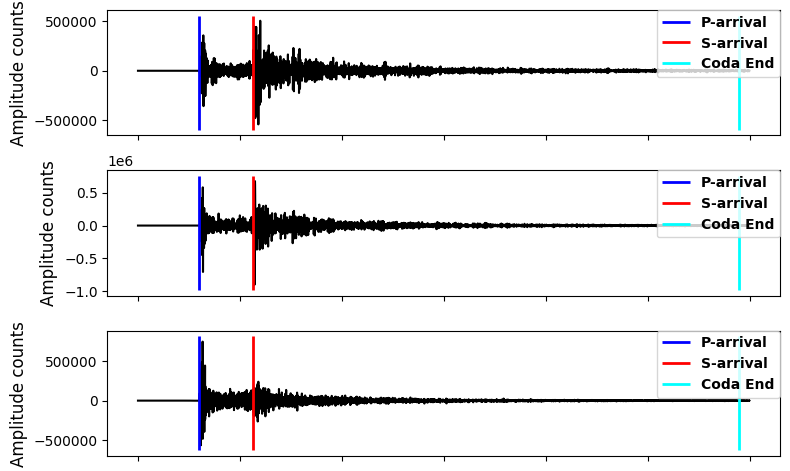

back_azimuth_deg 161.6
coda_end_sample [[5900.]]
network_code C1
p_arrival_sample 600.0
p_status manual
p_travel_sec 8.550000190734863
p_weight 0.5
receiver_code AC04
receiver_elevation_m 249.0
receiver_latitude -28.2046
receiver_longitude -71.0739
receiver_type HH
s_arrival_sample 1129.0
s_status manual
s_weight 0.5
snr_db [71.30000305 73.30000305 68.        ]
source_depth_km 44.67
source_depth_uncertainty_km None
source_distance_deg 0.05
source_distance_km 5.61
source_error_sec 1.7074
source_gap_deg 154.606
source_horizontal_uncertainty_km 8.87429
source_id 606918008
source_latitude -28.1566
source_longitude -71.0919
source_magnitude 4.2
source_magnitude_author None
source_magnitude_type mb
source_mechanism_strike_dip_rake None
source_origin_time 2014-06-16 23:19:54.05
source_origin_uncertainty_sec 0.78
trace_category earthquake_local
trace_name AC04.C1_20140616231955_EV
trace_start_time 2014-06-16 23:19:56.600000


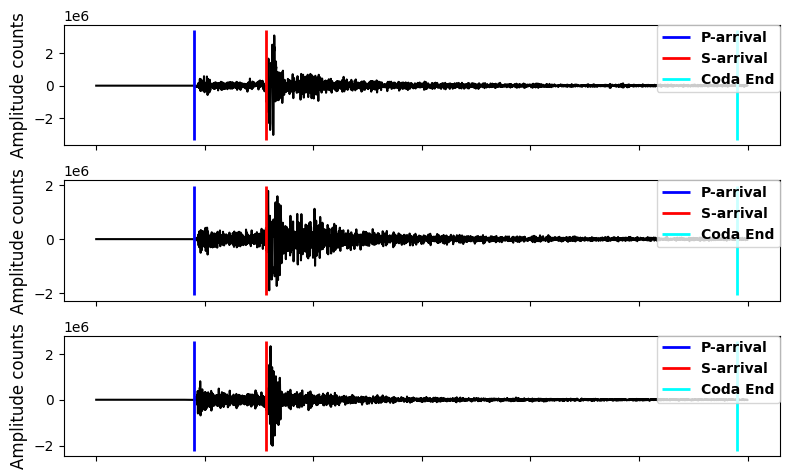

back_azimuth_deg 221.3
coda_end_sample [[5900.]]
network_code C1
p_arrival_sample 900.0
p_status manual
p_travel_sec 9.819999694824219
p_weight 0.5
receiver_code AC04
receiver_elevation_m 249.0
receiver_latitude -28.2046
receiver_longitude -71.0739
receiver_type HH
s_arrival_sample 1564.0
s_status manual
s_weight 0.5
snr_db [91.80000305 90.90000153 89.5       ]
source_depth_km 57.31
source_depth_uncertainty_km None
source_distance_deg 0.15
source_distance_km 16.63
source_error_sec 1.8363
source_gap_deg 99.899
source_horizontal_uncertainty_km 6.72619
source_id 604856436
source_latitude -28.0919
source_longitude -70.9621
source_magnitude 4.56
source_magnitude_author None
source_magnitude_type mb
source_mechanism_strike_dip_rake None
source_origin_time 2014-07-20 06:31:45.70
source_origin_uncertainty_sec 0.45
trace_category earthquake_local
trace_name AC04.C1_20140720063145_EV
trace_start_time 2014-07-20 06:31:46.520000


In [ ]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_name = "merge.hdf5"
csv_file = "merge.csv"

# reading the csv file into a dataframe:
df = pd.read_csv(csv_file)
print(f'total events in csv file: {len(df)}')
# filterering the dataframe
df = df[(df.trace_category == 'earthquake_local') & (df.source_distance_km <= 20) & (df.source_magnitude > 3)]
print(f'total events selected: {len(df)}')

# making a list of trace names for the selected data
ev_list = df['trace_name'].to_list()

# retrieving selected waveforms from the hdf5 file: 
dtfl = h5py.File(file_name, 'r')
for c, evi in enumerate(ev_list):
    dataset = dtfl.get('data/'+str(evi)) 
    # waveforms, 3 channels: first row: E channel, second row: N channel, third row: Z channel 
    data = np.array(dataset)

    fig = plt.figure()
    ax = fig.add_subplot(311)         
    plt.plot(data[:,0], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(312)         
    plt.plot(data[:,1], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(313)         
    plt.plot(data[:,2], 'k')
    plt.rcParams["figure.figsize"] = (8,5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    ymin, ymax = ax.get_ylim()
    pl = plt.vlines(dataset.attrs['p_arrival_sample'], ymin, ymax, color='b', linewidth=2, label='P-arrival')
    sl = plt.vlines(dataset.attrs['s_arrival_sample'], ymin, ymax, color='r', linewidth=2, label='S-arrival')
    cl = plt.vlines(dataset.attrs['coda_end_sample'], ymin, ymax, color='aqua', linewidth=2, label='Coda End')
    plt.legend(handles=[pl, sl, cl], loc = 'upper right', borderaxespad=0., prop=legend_properties)        
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])
    plt.show() 

    for at in dataset.attrs:
        print(at, dataset.attrs[at])    

    inp = input("Press a key to plot the next waveform!")
    if inp == "r":
        continue             

In [ ]:
# reading the csv file into a dataframe:
df = pd.read_csv(csv_file)
print(f'total events in csv file: {len(df)}')
# filterering the dataframe
df = df[(df.trace_category == 'noise') & (df.receiver_code == 'PHOB') ]
print(f'total events selected: {len(df)}')

# making a list of trace names for the selected data
ev_list = df['trace_name'].to_list()[:200]

# retrieving selected waveforms from the hdf5 file: 
dtfl = h5py.File(file_name, 'r')
for c, evi in enumerate(ev_list):
    dataset = dtfl.get('data/'+str(evi)) 
    # waveforms, 3 channels: first row: E channel, second row: N channel, third row: Z channel 
    data = np.array(dataset)

    fig = plt.figure()
    ax = fig.add_subplot(311)         
    plt.plot(data[:,0], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(312)         
    plt.plot(data[:,1], 'k')
    plt.rcParams["figure.figsize"] = (8, 5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()     
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])

    ax = fig.add_subplot(313)         
    plt.plot(data[:,2], 'k')
    plt.rcParams["figure.figsize"] = (8,5)
    legend_properties = {'weight':'bold'}    
    plt.tight_layout()     
    plt.ylabel('Amplitude counts', fontsize=12) 
    ax.set_xticklabels([])
    plt.show() 

    for at in dataset.attrs:
        print(at, dataset.attrs[at])    

    inp = input("Press a key to plot the next waveform!")
    if inp == "r":
        continue       